In [1]:
print('Hello_World')

Hello_World


## Installing Dependencies

In [6]:
!pip install gym-anytrading
!pip install stable-baselines3
!pip install gymnasium
!pip install torch
!pip install yfinance
!pip install pandas numpy matplotlib

   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 1.0/122.1 MB 5.3 MB/s eta 0:00:23
    --------------------------------------- 1.8/122.1 MB 4.5 MB/s eta 0:00:27
    --------------------------------------- 2.6/122.1 MB 4.3 MB/s eta 0:00:28
   - -------------------------------------- 3.4/122.1 MB 4.2 MB/s eta 0:00:29
   - -------------------------------------- 4.5/122.1 MB 4.1 MB/s eta 0:00:29
   - -------------------------------------- 5.2/122.1 MB 4.1 MB/s eta 0:00:29
   - -------------------------------------- 6.0/122.1 MB 4.0 MB/s eta 0:00:29
   -- ------------------------------------- 6.8/122.1 MB 4.0 MB/s eta 0:00:29
   -- ------------------------------------- 7.6/122.1 MB 4.0 MB/s eta 0:00:29
   -- ------------------------------------- 8.7/122.1 MB 4.0 MB/s eta 0:00:29
   --- ------------------------------------ 9.4/122.1 MB 4.0 MB/s eta 0:00:29
   --- ------------------------------------ 10.2/122.1 MB 4.0 MB/s eta 

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 4.0 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   -------------------------------- ------- 4/5 [yfinance]
   ---------------------------------------- 5/5 [yfinance]



In [11]:
# Gym {Interface btw Frameworks & Agents}
import gymnasium as gym
import gym_anytrading

# Stable baselines {Vectorized env. & frameworks}
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import A2C

# Processing libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

## Importing Data

In [12]:
df = pd.read_csv('Download Data - STOCK_US_XNYS_GME.csv')

In [13]:
df.head()

,Date,Open,High,Low,Close,Volume
0,07/21/2026,21.78,21.90,21.58,21.79,"2,916,158"
1,07/20/2026,21.89,21.98,21.67,21.76,"3,923,265"
2,07/17/2026,21.86,22.07,21.67,21.89,"2,624,234"
3,07/16/2026,22.30,22.51,21.86,21.92,"3,517,633"
4,07/15/2026,22.49,22.62,22.16,22.26,"2,560,795"


In [15]:
df.shape

(253, 6)

In [17]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume            object
dtype: object

In [19]:
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2026-07-21,21.78,21.90,21.58,21.79,"2,916,158"
2026-07-20,21.89,21.98,21.67,21.76,"3,923,265"
2026-07-17,21.86,22.07,21.67,21.89,"2,624,234"
2026-07-16,22.30,22.51,21.86,21.92,"3,517,633"
2026-07-15,22.49,22.62,22.16,22.26,"2,560,795"


In [29]:
# Creating environment for agent from dataframe

env = gym.make('stocks-v0', df=df, frame_bound=(5,100), window_size=5)  #5 days for observation before it begin to trade 

In [28]:
print(type(env))                   #using wrappers
print(type(env.unwrapped))

<class 'gymnasium.wrappers.common.OrderEnforcing'>
<class 'gym_anytrading.envs.stocks_env.StocksEnv'>


In [24]:
env.unwrapped.prices

array([21.79, 21.76, 21.89, 21.92, 22.26, 22.43, 22.03, 21.68, 21.95,
       21.7 , 22.2 , 22.76, 22.82, 22.64, 22.08, 22.03, 21.76, 21.01,
       21.44, 21.08, 21.14, 21.52, 21.51, 21.46, 21.74, 21.77, 22.18,
       22.42, 22.28, 22.26, 21.8 , 22.27, 22.18, 20.92, 21.36, 21.18,
       21.68, 21.68, 21.91, 21.96, 21.96, 22.49, 22.55, 22.1 , 21.91,
       21.59, 21.61, 22.08, 22.37, 23.17, 24.28, 23.97, 25.17, 24.23,
       23.84, 26.53, 24.95, 24.52, 25.09, 25.41, 24.95, 25.01, 25.66,
       24.46, 24.92, 24.55, 25.18, 24.79, 24.03, 23.4 , 23.22, 22.87,
       22.91, 23.43, 23.08, 23.36, 22.76, 23.04, 22.27, 22.1 , 22.56,
       23.08, 22.81, 23.03, 22.57, 23.23, 23.36, 23.59, 23.28, 23.53,
       24.43, 24.46, 24.37, 24.8 , 24.37, 23.88, 23.87, 23.82, 24.2 ,
       24.03], dtype=float32)

In [25]:
env.unwrapped.signal_features

array([[ 2.179e+01,  0.000e+00],
       [ 2.176e+01, -3.000e-02],
       [ 2.189e+01,  1.300e-01],
       [ 2.192e+01,  3.000e-02],
       [ 2.226e+01,  3.400e-01],
       [ 2.243e+01,  1.700e-01],
       [ 2.203e+01, -4.000e-01],
       [ 2.168e+01, -3.500e-01],
       [ 2.195e+01,  2.700e-01],
       [ 2.170e+01, -2.500e-01],
       [ 2.220e+01,  5.000e-01],
       [ 2.276e+01,  5.600e-01],
       [ 2.282e+01,  6.000e-02],
       [ 2.264e+01, -1.800e-01],
       [ 2.208e+01, -5.600e-01],
       [ 2.203e+01, -5.000e-02],
       [ 2.176e+01, -2.700e-01],
       [ 2.101e+01, -7.500e-01],
       [ 2.144e+01,  4.300e-01],
       [ 2.108e+01, -3.600e-01],
       [ 2.114e+01,  6.000e-02],
       [ 2.152e+01,  3.800e-01],
       [ 2.151e+01, -1.000e-02],
       [ 2.146e+01, -5.000e-02],
       [ 2.174e+01,  2.800e-01],
       [ 2.177e+01,  3.000e-02],
       [ 2.218e+01,  4.100e-01],
       [ 2.242e+01,  2.400e-01],
       [ 2.228e+01, -1.400e-01],
       [ 2.226e+01, -2.000e-02],
       [ 2

In [30]:
print(env.observation_space)

Box(-1e+10, 1e+10, (5, 2), float32)


In [33]:
obs, info = env.reset()

print(type(obs))
print(obs.shape)

<class 'numpy.ndarray'>
(5, 2)


In [34]:
print(env.action_space)

Discrete(2)


In [36]:
action = env.action_space.sample()
print(action)

1


## Build Environment

In [39]:
obs, info = env.reset()

for i in range(10):
    action = env.action_space.sample()

    obs, reward, terminated, truncated, info = env.step(action)

    print(f"Step {i+1}")
    print(f"Action : {action}")
    print(f"Reward : {reward}")
    print(f"Info   : {info}")
    print("-" * 40)

    if terminated or truncated:
        break

Step 1
Action : 1
Reward : 0
Info   : {'total_reward': 0.0, 'total_profit': 1.0, 'position': <Positions.Long: 1>}
----------------------------------------
Step 2
Action : 1
Reward : 0
Info   : {'total_reward': 0.0, 'total_profit': 1.0, 'position': <Positions.Long: 1>}
----------------------------------------
Step 3
Action : 1
Reward : 0
Info   : {'total_reward': 0.0, 'total_profit': 1.0, 'position': <Positions.Long: 1>}
----------------------------------------
Step 4
Action : 0
Reward : -0.3299999237060547
Info   : {'total_reward': np.float32(-0.32999992), 'total_profit': np.float32(0.9702943), 'position': <Positions.Short: 0>}
----------------------------------------
Step 5
Action : 0
Reward : 0
Info   : {'total_reward': np.float32(-0.32999992), 'total_profit': np.float32(0.9702943), 'position': <Positions.Short: 0>}
----------------------------------------
Step 6
Action : 0
Reward : 0
Info   : {'total_reward': np.float32(-0.32999992), 'total_profit': np.float32(0.9702943), 'position'

In [50]:
import matplotlib.pyplot as plt

obs, info = env.reset()
done = False

while not done:

    action = env.action_space.sample()                             #Random_Agents
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

{'total_reward': np.float32(-4.130001), 'total_profit': np.float32(0.63104725), 'position': <Positions.Short: 0>}


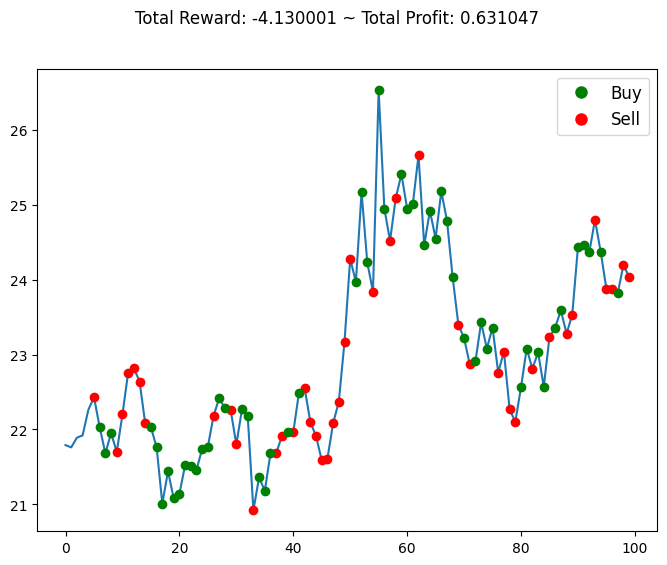

In [51]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(8,6))
plt.cla()

env.unwrapped.render_all()

legend_elements = [
    Line2D([0], [0],
           marker='o',
           color='w',
           markerfacecolor='green',
           markersize=10,
           label='Buy'),

    Line2D([0], [0],
           marker='o',
           color='w',
           markerfacecolor='red',
           markersize=10,
           label='Sell')
]

plt.legend(handles=legend_elements,
           loc='upper right',
           frameon=True,
           fontsize=12)
print(info)
plt.show()

## Building Environment & Train 

In [52]:
env_maker = lambda: gym.make('stocks-v0', df=df, frame_bound=(5,100), window_size=5)
env = DummyVecEnv([env_maker])

In [55]:
from stable_baselines3 import A2C

model = A2C(
    "MlpPolicy",
    env,
    verbose=1
)

model.learn(total_timesteps=100000)

Using cpu device
------------------------------------
| time/                 |          |
|    fps                | 284      |
|    iterations         | 100      |
|    time_elapsed       | 1        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.693   |
|    explained_variance | -0.0291  |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 0.0125   |
|    value_loss         | 0.000867 |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 274      |
|    iterations         | 200      |
|    time_elapsed       | 3        |
|    total_timesteps    | 1000     |
| train/                |          |
|    entropy_loss       | -0.688   |
|    explained_variance | 0.075    |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
|    policy_loss        | 0.491    |
|    value_loss      

## Evaluation

In [56]:
model.save("A2C_GME_100k")

In [58]:
result = env.reset()

print(type(result))
print(result)

<class 'numpy.ndarray'>
[[[21.76 -0.03]
  [21.89  0.13]
  [21.92  0.03]
  [22.26  0.34]
  [22.43  0.17]]]


In [59]:
obs = env.reset()

done = False

while not done:

    action, _ = model.predict(obs, deterministic=True)

    obs, reward, done, info = env.step(action)

print(info)

[{'total_reward': 0.0, 'total_profit': 1.0, 'position': <Positions.Short: 0>, 'TimeLimit.truncated': True, 'terminal_observation': array([[ 2.388e+01, -4.900e-01],
       [ 2.387e+01, -1.000e-02],
       [ 2.382e+01, -5.000e-02],
       [ 2.420e+01,  3.800e-01],
       [ 2.403e+01, -1.700e-01]], dtype=float32)}]


In [60]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(16,6))

env.unwrapped.render_all()

legend = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='green', markersize=10, label='Buy'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='red', markersize=10, label='Sell')
]

plt.legend(handles=legend)
plt.show()

AttributeError: 'DummyVecEnv' object has no attribute 'render_all'

<Figure size 1600x600 with 0 Axes>

In [61]:
obs = env.reset()

actions = []

for i in range(20):

    action, _ = model.predict(obs, deterministic=True)

    actions.append(action)

    obs, reward, done, info = env.step(action)

    if done:
        break

print(actions)

[array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0])]


In [62]:
print(model.policy)

ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=10, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=10, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=64, out_features=2, bias=True)
  (value_net): Linear(in_features=64, out_features=1, bias=True)
)


In [63]:
import torch

obs = env.reset()

obs_tensor = torch.tensor(obs, dtype=torch.float32)

obs_tensor = obs_tensor.unsqueeze(0)

distribution = model.policy.get_distribution(obs_tensor)

print(distribution.distribution.probs)

tensor([[9.9999e-01, 1.2846e-05]], grad_fn=<SoftmaxBackward0>)


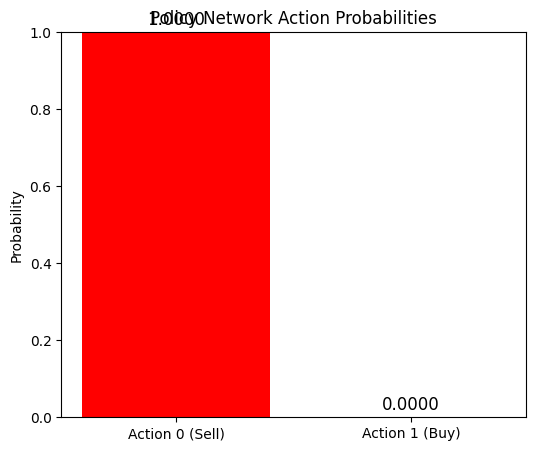

In [64]:
import matplotlib.pyplot as plt

probs = distribution.distribution.probs.detach().numpy()[0]

plt.figure(figsize=(6,5))

plt.bar(["Action 0 (Sell)", "Action 1 (Buy)"], probs,
        color=["red","green"])

plt.ylabel("Probability")
plt.title("Policy Network Action Probabilities")
plt.ylim(0,1)

for i,p in enumerate(probs):
    plt.text(i,p+0.02,f"{p:.4f}",ha="center",fontsize=12)

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_15496\476003261.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actions.append(int(action))


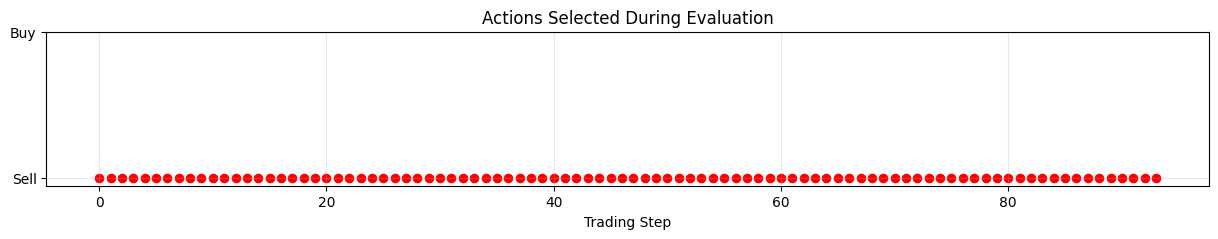

In [65]:
actions = []

obs = env.reset()

for _ in range(95):
    action,_ = model.predict(obs, deterministic=True)

    actions.append(int(action))

    obs,reward,done,info = env.step(action)

    if done:
        break

plt.figure(figsize=(15,2))

plt.scatter(range(len(actions)),
            actions,
            color="red",
            s=35)

plt.yticks([0,1],["Sell","Buy"])
plt.xlabel("Trading Step")
plt.title("Actions Selected During Evaluation")

plt.grid(alpha=.3)
plt.show()

In [66]:
prices = env.unwrapped.prices[:len(actions)]

plt.figure(figsize=(15,6))

plt.plot(prices,label="Stock Price",linewidth=2)

sell_idx = [i for i,a in enumerate(actions) if a==0]
buy_idx  = [i for i,a in enumerate(actions) if a==1]

plt.scatter(sell_idx,
            prices[sell_idx],
            c="red",
            s=80,
            marker="v",
            label="Sell")

plt.scatter(buy_idx,
            prices[buy_idx],
            c="green",
            s=80,
            marker="^",
            label="Buy")

plt.legend()
plt.title("A2C Trading Decisions")
plt.show()

AttributeError: 'DummyVecEnv' object has no attribute 'prices'

C:\Users\HP\AppData\Local\Temp\ipykernel_15496\3105484299.py:11: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  confidences.append(float(probs.max()))


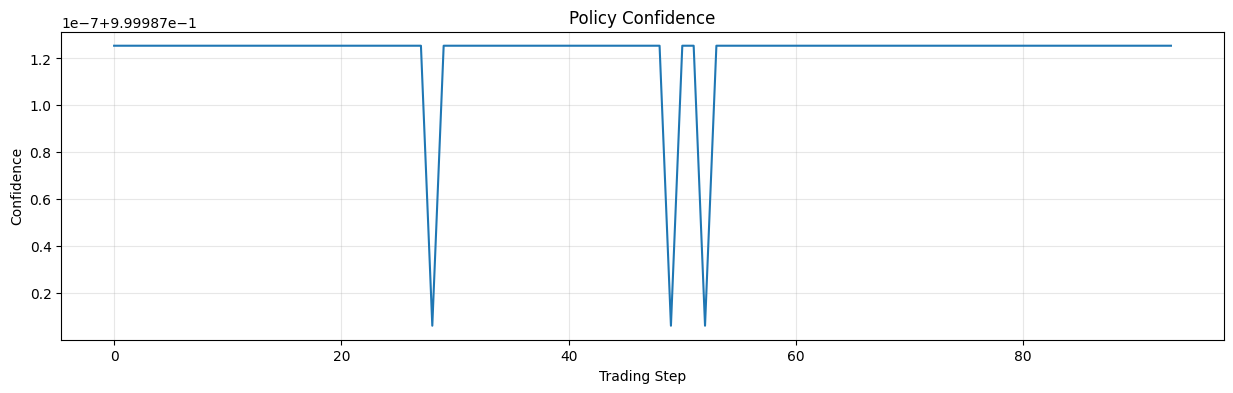

In [67]:
confidences=[]

obs=env.reset()

for _ in range(95):

    obs_tensor=torch.tensor(obs,dtype=torch.float32).unsqueeze(0)

    probs=model.policy.get_distribution(obs_tensor).distribution.probs

    confidences.append(float(probs.max()))

    action,_=model.predict(obs)

    obs,reward,done,info=env.step(action)

    if done:
        break

plt.figure(figsize=(15,4))

plt.plot(confidences)

plt.ylabel("Confidence")

plt.xlabel("Trading Step")

plt.title("Policy Confidence")

plt.grid(alpha=.3)

plt.show()